# Grupo 4 — Random Forest
## Notebook 2: Implementación Con Librerias
**Inteligencia Artificial I — Actividad 2**
Fundación Universitaria Los Libertadores

---

## 1. Introduccion
### ¿Qué problema se va a resolver?

Se busca predecir si un pasajero del Titanic sobrevivió o no, usando variables como edad, sexo, clase y tarifa.

### ¿Por qué es importante?

Permite entender qué factores influyeron en la supervivencia, lo cual es útil en análisis predictivo y toma de decisiones.

### Descripción del dataset

El dataset contiene información de pasajeros del Titanic, incluyendo:

Survived: Variable objetivo (0 = No, 1 = Sí)
Pclass: Clase del pasajero
Sex: Género
Age: Edad
Fare: Tarifa pagada
Embarked: Puerto de embarque

## 2. Carga y Exploración de Datos
Aquí se carga el archivo CSV en un DataFrame usando pandas, luego se analizan estadísticas con **describe()** y se visualizan registros iniciales. Esto permite entender qué tipo de datos se tienen, detectar valores nulos y conocer la distribución general.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/titanic.csv")

print(df.describe())


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


##3. Análisis Exploratorio de Datos (EDA)
En esta parte se exploran visualmente los datos mediante gráficos. Se analizan distribuciones de variables, correlaciones entre ellas, la proporción de sobrevivientes y posibles valores atípicos. El objetivo es descubrir patrones y relaciones importantes antes de entrenar el modelo.

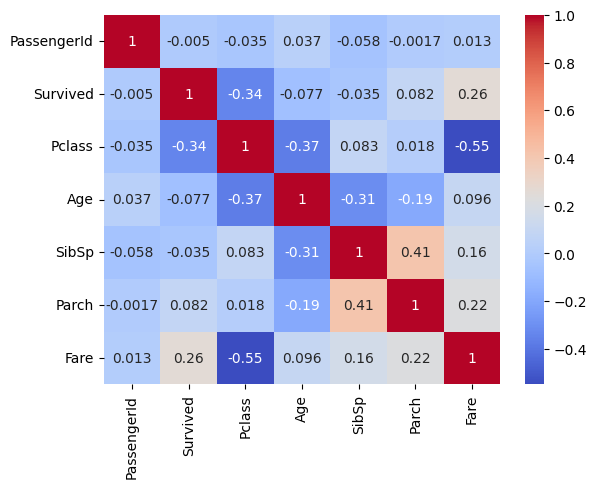

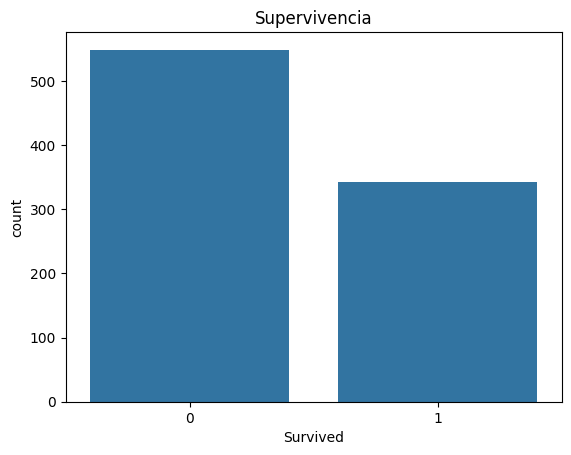

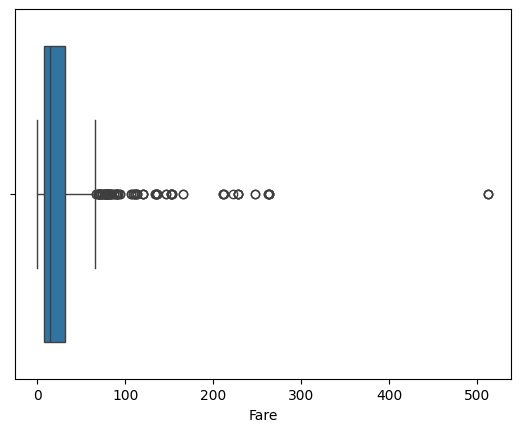

In [10]:
 #Correlaciones
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

#Variable Objetivo
sns.countplot(x="Survived", data=df)
plt.title("Supervivencia")
plt.show()

#Outliers
sns.boxplot(x=df["Fare"])
plt.show()

##4.Preprocesamiento
Se preparan los datos para el modelo. Se eliminan columnas irrelevantes, se rellenan valores nulos (como la edad con la mediana), y se transforman variables categóricas a numéricas (por ejemplo, Sex a 0 y 1). Además, se dividen los datos en entrenamiento (80%) y prueba (20%), lo cual es clave para evaluar el modelo correctamente.

In [11]:
# Eliminar columnas innecesarias
df = df.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1)

# Codificación
#convierte el sexo a número siendo mujer a 0 y hombre a 1
df["Sex"] = df["Sex"].map({"female": 0, "male": 1})

# Embarked sí en dummies
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Variables
X = df.drop("Survived", axis=1)
y = df["Survived"]

# División
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##5. Entrenamiento del Modelo
Aquí se crea el modelo de Random Forest usando sklearn y se entrena con los datos de entrenamiento. El modelo aprende patrones a partir de múltiples árboles de decisión para poder predecir si un pasajero sobrevivirá o no.

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
import joblib

joblib.dump(model, '../models/modelo.pkl')

['../models/modelo.pkl']

## 6. Evaluacion del Modelo
Se evalúa qué tan bien funciona el modelo usando los datos de prueba. Se calculan métricas como accuracy, precision, recall y F1-score, y se genera una matriz de confusión para visualizar aciertos y errores. Esto permite medir el rendimiento real del modelo.

Accuracy: 0.8212290502793296
Precision: 0.8
Recall: 0.7567567567567568
F1 Score: 0.7777777777777778


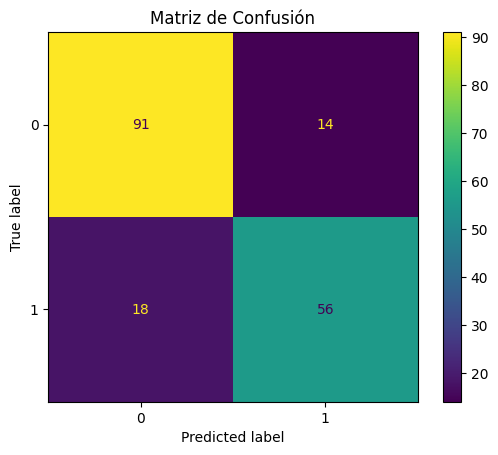

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matriz de Confusión")
plt.show()

## 7. Ajuste de Hiperparámetros
En esta sección se prueban diferentes configuraciones del modelo (como número de árboles o profundidad) usando técnicas como Grid Search. El objetivo es encontrar la mejor combinación de parámetros para mejorar la precisión del modelo.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


## 8. Interpretación de Resultados
Se analiza qué variables fueron más importantes en las predicciones del modelo (feature importance). También se revisan los errores para entender en qué casos falla. Esto ayuda a explicar el comportamiento del modelo y validar si tiene sentido con la realidad.

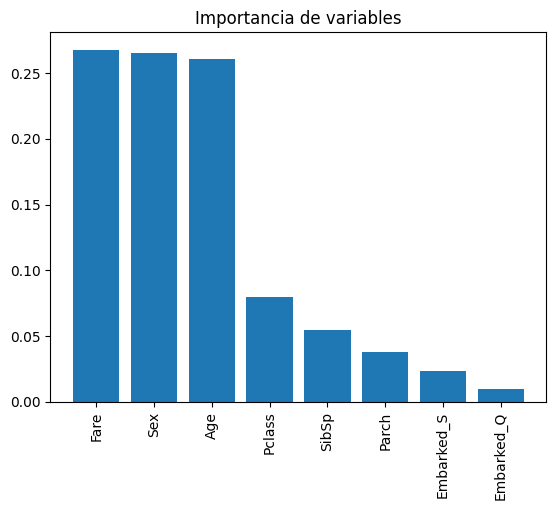

In [15]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Importancia de variables")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.show()

## Prueba de funcionamiento

In [16]:
# Supervivencia por género
print("Supervivencia por género (0 = mujer, 1 = hombre):")
print(df.groupby("Sex")["Survived"].mean())


Supervivencia por género (0 = mujer, 1 = hombre):
Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64


## 9. Conclusiones
El modelo de Random Forest presenta un buen desempeño, alcanzando una precisión aproximada entre el 75% y el 85%, lo que indica que es capaz de predecir de manera adecuada la supervivencia de los pasajeros. Además, logra identificar correctamente patrones relevantes, como la influencia del género y la edad, evidenciando que mujeres y niños tenían mayor probabilidad de sobrevivir. Sin embargo, el modelo tiene limitaciones, principalmente por la presencia de datos faltantes que fueron reemplazados y por la falta de variables más representativas que incluyan factores reales del contexto del accidente.